In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import scipy as sp
from functools import partial

from tqdm.auto import tqdm

# Optional: pydicom is not used by this solution, but keep import if available.
try:
    import pydicom  # noqa: F401
except Exception:
    pydicom = None

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)



In [2]:
# Fix wrong path typo and use the standard Kaggle input path
BASE_PATH = "../input/osic-pulmonary-fibrosis-progression"

train_path = os.path.join(BASE_PATH, "train.csv")
test_path = os.path.join(BASE_PATH, "test.csv")
sample_sub_path = os.path.join(BASE_PATH, "sample_submission.csv")

train_df_raw = pd.read_csv(train_path)
test_df_raw = pd.read_csv(test_path)

print("Training data shape:", train_df_raw.shape)
print("Test data shape:", test_df_raw.shape)
train_df_raw.head()



Training data shape: (1394, 7)
Test data shape: (18, 7)


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked
1,ID00133637202223847701934,2,3203,93.088817,83,Male,Never smoked
2,ID00133637202223847701934,4,3097,90.008138,83,Male,Never smoked
3,ID00133637202223847701934,6,3171,92.158800,83,Male,Never smoked
4,ID00133637202223847701934,8,3115,90.531272,83,Male,Never smoked


In [3]:
# Build pairwise training rows (base visit -> predict visit) per patient, as in original logic
train_df = train_df_raw.copy()
train_df["Patient_Week"] = (
    train_df["Patient"].astype(str) + "_" + train_df["Weeks"].astype(str)
)

output = pd.DataFrame()
gb = train_df.groupby("Patient")
tk0 = tqdm(gb, total=len(gb))
for _, usr_df in tk0:
    usr_output = pd.DataFrame()
    for week, tmp in usr_df.groupby("Weeks"):
        rename_cols = {
            "Weeks": "base_Week",
            "FVC": "base_FVC",
            "Percent": "base_Percent",
            "Age": "base_Age",
        }
        tmp = tmp.drop(columns="Patient_Week").rename(columns=rename_cols)
        drop_cols = ["Age", "Sex", "SmokingStatus", "Percent"]
        _usr_output = (
            usr_df.drop(columns=drop_cols)
            .rename(columns={"Weeks": "predict_Week"})
            .merge(tmp, on="Patient")
        )
        _usr_output["Week_passed"] = (
            _usr_output["predict_Week"] - _usr_output["base_Week"]
        )
        usr_output = pd.concat([usr_output, _usr_output], axis=0, ignore_index=True)
    output = pd.concat([output, usr_output], axis=0, ignore_index=True)

train_df = output[output["Week_passed"] != 0].reset_index(drop=True)
print("Pairwise training shape:", train_df.shape)
train_df.head()



  0%|          | 0/158 [00:00<?, ?it/s]

Pairwise training shape: (10952, 11)


,Patient,predict_Week,FVC,Patient_Week,base_Week,base_FVC,base_Percent,base_Age,Sex,SmokingStatus,Week_passed
0,ID00007637202177411956430,5,2214,ID00007637202177411956430_5,-4,2315,58.253649,79,Male,Ex-smoker,9
1,ID00007637202177411956430,7,2061,ID00007637202177411956430_7,-4,2315,58.253649,79,Male,Ex-smoker,11
2,ID00007637202177411956430,9,2144,ID00007637202177411956430_9,-4,2315,58.253649,79,Male,Ex-smoker,13
3,ID00007637202177411956430,11,2069,ID00007637202177411956430_11,-4,2315,58.253649,79,Male,Ex-smoker,15
4,ID00007637202177411956430,17,2101,ID00007637202177411956430_17,-4,2315,58.253649,79,Male,Ex-smoker,21


In [4]:
# One-hot encode categorical columns, keep the original renaming scheme
train_df = pd.get_dummies(train_df, columns=["Sex"])
train_df = pd.get_dummies(train_df, columns=["SmokingStatus"])
train_df = train_df.rename(
    columns={
        "Sex_Female": "Female",
        "Sex_Male": "Male",
        "SmokingStatus_Currently smokes": "CurrentlySmokes",
        "SmokingStatus_Ex-smoker": "ExSmoker",
        "SmokingStatus_Never smoked": "NeverSmoked",
    }
)
train_df.head()



,Patient,predict_Week,FVC,Patient_Week,base_Week,base_FVC,base_Percent,base_Age,Week_passed,Female,Male,CurrentlySmokes,ExSmoker,NeverSmoked
0,ID00007637202177411956430,5,2214,ID00007637202177411956430_5,-4,2315,58.253649,79,9,False,True,False,True,False
1,ID00007637202177411956430,7,2061,ID00007637202177411956430_7,-4,2315,58.253649,79,11,False,True,False,True,False
2,ID00007637202177411956430,9,2144,ID00007637202177411956430_9,-4,2315,58.253649,79,13,False,True,False,True,False
3,ID00007637202177411956430,11,2069,ID00007637202177411956430_11,-4,2315,58.253649,79,15,False,True,False,True,False
4,ID00007637202177411956430,17,2101,ID00007637202177411956430_17,-4,2315,58.253649,79,21,False,True,False,True,False


In [5]:
X = train_df.drop(
    ["Patient", "FVC", "base_Week", "predict_Week", "Patient_Week"], axis=1
)
y = train_df["FVC"].astype(float)

print("Feature matrix shape:", X.shape)



Feature matrix shape: (10952, 9)


In [6]:
from sklearn import model_selection

X_train, X_valid, y_train, y_valid = model_selection.train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(
    f"training data has {X_train.shape[0]} observation with {X_train.shape[1]} features"
)
print(
    f"validation data has {X_valid.shape[0]} observation with {X_valid.shape[1]} features"
)



training data has 8761 observation with 9 features
validation data has 2191 observation with 9 features


In [7]:
from sklearn.preprocessing import MinMaxScaler

# IMPORTANT: fit scaler on training features and reuse everywhere (valid + submission)
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_s = scaler.transform(X_train)
X_valid_s = scaler.transform(X_valid)



In [8]:
import xgboost as xgb
from xgboost import XGBRegressor

# Keep original model usage; define a baseline regressor (not used later but kept)
regr_XGB = XGBRegressor(random_state=RANDOM_STATE)



In [9]:
regr_XGB.fit(X_train_s, y_train)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=0, ...)

In [10]:
# Fix XGBoostError: missing=None is invalid in newer xgboost; use np.nan
regr_XGB_opt = XGBRegressor(
    base_score=0.5,
    booster="gbtree",
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=0.8999999999999999,
    eta=0.01,
    gamma=0,
    gpu_id=-1,
    importance_type="gain",
    interaction_constraints="",
    learning_rate=0.300000012,
    max_delta_step=0,
    max_depth=5,
    min_child_weight=1,
    missing=np.nan,  # bugfix
    monotone_constraints="()",
    n_estimators=100,
    n_jobs=0,
    num_parallel_tree=1,
    random_state=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    subsample=0.7999999999999999,
    tree_method="exact",
    validate_parameters=1,
    verbosity=None,
)



In [11]:
regr_XGB_opt.fit(X_train_s, y_train)
y_pred_valid = regr_XGB_opt.predict(X_valid_s)
print("Valid preds:", y_pred_valid[:5])



Valid preds: [2765.9375 2741.6797 2690.1797 2838.293  2833.955 ]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [08:02:03] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)


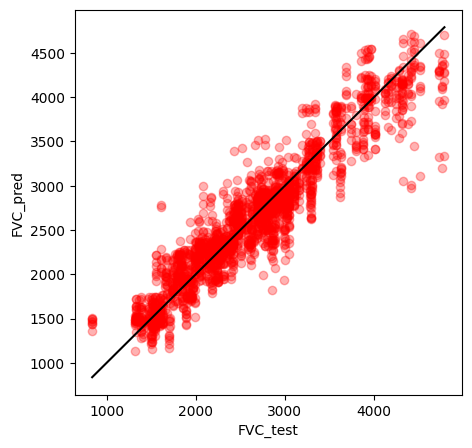

In [12]:
# Plot (optional; should not error)
plt.figure(figsize=(5, 5))
plt.scatter(y_valid, y_pred_valid, color="r", alpha=0.3)
plt.plot([min(y_valid), max(y_valid)], [min(y_valid), max(y_valid)], color="k")
plt.xlabel("FVC_test")
plt.ylabel("FVC_pred")
plt.rcParams.update({"font.size": 12})
plt.show()



In [13]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
print("RMSE:", rmse)



RMSE: 269.59570945418665


In [14]:
# Keep the CV cell but ensure it runs (avoid early stopping setting changes; retain original)
data_dmatrix = xgb.DMatrix(data=X, label=y)
params = {
    "objective": "reg:squarederror",
    "colsample_bytree": 0.3,
    "learning_rate": 0.1,
    "max_depth": 5,
    "alpha": 10,
}
cv_results = xgb.cv(
    dtrain=data_dmatrix,
    params=params,
    nfold=10,
    num_boost_round=200,
    early_stopping_rounds=10,
    metrics="rmse",
    as_pandas=True,
    seed=123,
)
print((cv_results["test-rmse-mean"]).tail(1))



199    205.282152
Name: test-rmse-mean, dtype: float64


In [15]:
# Feature importances from baseline model (may be all zeros depending on fit)
importances = regr_XGB.feature_importances_
indices = np.argsort(importances)[::-1]
print("Feature importance ranking by XGBoost Model:")
for ind in range(X.shape[1]):
    print(f"{X.columns[indices[ind]]} : {importances[indices[ind]]:.4f}")



Feature importance ranking by XGBoost Model:
base_FVC : 0.8032
CurrentlySmokes : 0.0635
NeverSmoked : 0.0305
ExSmoker : 0.0258
base_Age : 0.0231
Female : 0.0213
base_Percent : 0.0190
Week_passed : 0.0136
Male : 0.0000


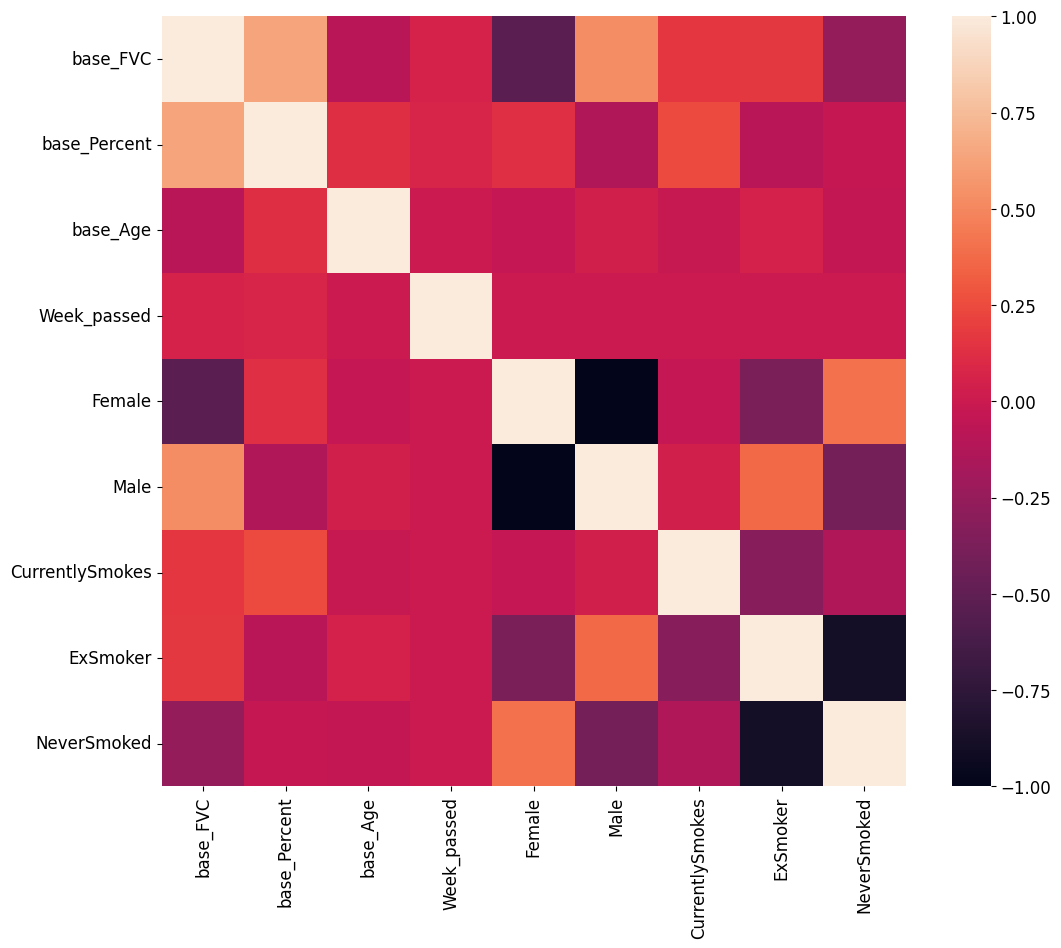

In [16]:
# Optional correlation heatmap; keep but safe
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pd.DataFrame(X, columns=X.columns).corr(), annot=False, ax=ax)
plt.show()



In [17]:
# Build train/valid analysis frames (fix previous crash by using successful predictions)
FVC_pred_train = regr_XGB_opt.predict(X_train_s)
train_eval_df = pd.DataFrame(X_train_s, columns=X.columns)
train_eval_df["FVC"] = np.asarray(y_train)
train_eval_df["FVC_pred"] = FVC_pred_train

FVC_pred_valid = regr_XGB_opt.predict(X_valid_s)
valid_eval_df = pd.DataFrame(X_valid_s, columns=X.columns)
valid_eval_df["FVC"] = np.asarray(y_valid)
valid_eval_df["FVC_pred"] = FVC_pred_valid

print(train_eval_df.head())



   base_FVC  base_Percent  base_Age  Week_passed  Female  Male  \
0   0.34689       0.25655  0.756757     0.571429     0.0   1.0   
1   0.34689       0.25655  0.756757     0.587302     0.0   1.0   
2   0.34689       0.25655  0.756757     0.603175     0.0   1.0   
3   0.34689       0.25655  0.756757     0.619048     0.0   1.0   
4   0.34689       0.25655  0.756757     0.666667     0.0   1.0   

   CurrentlySmokes  ExSmoker  NeverSmoked     FVC     FVC_pred  
0              0.0       1.0          0.0  2214.0  2114.954834  
1              0.0       1.0          0.0  2061.0  2112.758301  
2              0.0       1.0          0.0  2144.0  2103.496338  
3              0.0       1.0          0.0  2069.0  2054.535889  
4              0.0       1.0          0.0  2101.0  2108.620117  


In [18]:
# Quick internal score estimate using constant confidence (not Kaggle-eval exact for test, but sanity check)
train_eval_df["Confidence"] = 100.0
sigma_clipped = np.maximum(train_eval_df["Confidence"].values, 70.0)
delta = np.minimum(
    np.abs(train_eval_df["FVC"].values - train_eval_df["FVC_pred"].values), 1000.0
)
score = (-np.sqrt(2.0) * delta / sigma_clipped) - np.log(np.sqrt(2.0) * sigma_clipped)
print("Mean train metric (approx):", float(np.mean(score)))




Mean train metric (approx): -6.249347786044609


In [19]:
# Keep original optimization idea but apply to valid_eval_df so it actually runs.
# (This is diagnostic only; not used for submission due to runtime/benefit tradeoff.)
def loss_func(weight, row):
    confidence = float(weight[0]) if hasattr(weight, "__len__") else float(weight)
    sigma_clipped = max(confidence, 70.0)
    diff = abs(float(row["FVC"]) - float(row["FVC_pred"]))
    delta = min(diff, 1000.0)
    score = -np.sqrt(2.0) * delta / sigma_clipped - np.log(np.sqrt(2.0) * sigma_clipped)
    return -score


results = []
tk0 = tqdm(valid_eval_df.iterrows(), total=len(valid_eval_df))
for _, row in tk0:
    # For stability: constrain to positive confidence values
    loss_partial = partial(loss_func, row=row)
    x0 = np.array([100.0], dtype=float)
    bounds = [(1.0, 2000.0)]
    result = sp.optimize.minimize(loss_partial, x0, method="SLSQP", bounds=bounds)
    results.append(float(result.x[0]))

print("Optimized confidence sample:", results[:5])



  0%|          | 0/2191 [00:00<?, ?it/s]

Optimized confidence sample: [1.0, 158.84071795294076, 283.9883118877744, 100.0, 13.01704752445238]


In [20]:
# Evaluate optimized confidence on valid (diagnostic)
valid_eval_tmp = valid_eval_df.copy()
valid_eval_tmp["Confidence"] = results
sigma_clipped = np.maximum(valid_eval_tmp["Confidence"].values, 70.0)
delta = np.minimum(
    np.abs(valid_eval_tmp["FVC"].values - valid_eval_tmp["FVC_pred"].values), 1000.0
)
score = (-np.sqrt(2.0) * delta / sigma_clipped) - np.log(np.sqrt(2.0) * sigma_clipped)
print("Mean valid metric (optimized confidence, diagnostic):", float(np.mean(score)))



Mean valid metric (optimized confidence, diagnostic): -6.600309482895199


In [21]:
# Prepare test rows exactly matching sample_submission Patient_Week grid
test_base = pd.read_csv(test_path).rename(
    columns={
        "Weeks": "base_Week",
        "FVC": "base_FVC",
        "Percent": "base_Percent",
        "Age": "base_Age",
    }
)
submission = pd.read_csv(sample_sub_path)

submission["Patient"] = submission["Patient_Week"].apply(lambda x: x.split("_")[0])
submission["predict_Week"] = (
    submission["Patient_Week"].apply(lambda x: x.split("_")[1]).astype(int)
)

test_grid = submission.drop(columns=["FVC", "Confidence"]).merge(
    test_base, on="Patient", how="left"
)
test_grid["Week_passed"] = test_grid["predict_Week"] - test_grid["base_Week"]

print("Test grid shape:", test_grid.shape)
test_grid.head()



Test grid shape: (1908, 10)


,Patient_Week,Patient,predict_Week,base_Week,base_FVC,base_Percent,base_Age,Sex,SmokingStatus,Week_passed
0,ID00126637202218610655908_-3,ID00126637202218610655908,-3,18,2375,59.375,78,Male,Ex-smoker,-21
1,ID00126637202218610655908_-2,ID00126637202218610655908,-2,18,2375,59.375,78,Male,Ex-smoker,-20
2,ID00126637202218610655908_-1,ID00126637202218610655908,-1,18,2375,59.375,78,Male,Ex-smoker,-19
3,ID00126637202218610655908_0,ID00126637202218610655908,0,18,2375,59.375,78,Male,Ex-smoker,-18
4,ID00126637202218610655908_1,ID00126637202218610655908,1,18,2375,59.375,78,Male,Ex-smoker,-17


In [22]:
# One-hot encode test and align columns with training features
test_grid = pd.get_dummies(test_grid, columns=["Sex"])
test_grid = pd.get_dummies(test_grid, columns=["SmokingStatus"])
test_grid = test_grid.rename(
    columns={
        "Sex_Female": "Female",
        "Sex_Male": "Male",
        "SmokingStatus_Currently smokes": "CurrentlySmokes",
        "SmokingStatus_Ex-smoker": "ExSmoker",
        "SmokingStatus_Never smoked": "NeverSmoked",
    }
)

# Build test feature matrix in the same column order as X (training features)
# Fill missing dummy columns with 0, and extra columns are dropped.
X_test_sub = test_grid.reindex(columns=X.columns, fill_value=0)

print("Aligned test feature matrix shape:", X_test_sub.shape)



Aligned test feature matrix shape: (1908, 9)


In [23]:
# Transform using training-fitted scaler (bugfix: do NOT fit scaler on test)
X_test_sub_s = scaler.transform(X_test_sub)



In [24]:
# Predict submission FVC
FVC_pred_sub = regr_XGB_opt.predict(X_test_sub_s)

# Confidence: use a reasonable constant (>=70); keep simple and stable
CONFIDENCE_CONST = 200.0

submission_out = pd.DataFrame(
    {
        "Patient_Week": submission["Patient_Week"].values,
        "FVC": FVC_pred_sub.astype(float),
        "Confidence": np.full(len(submission), CONFIDENCE_CONST, dtype=float),
    }
)

submission_out.head()



,Patient_Week,FVC,Confidence
0,ID00126637202218610655908_-3,2398.832520,200.0
1,ID00126637202218610655908_-2,2398.832520,200.0
2,ID00126637202218610655908_-1,2398.832520,200.0
3,ID00126637202218610655908_0,2398.832520,200.0
4,ID00126637202218610655908_1,2353.420166,200.0


In [25]:
# Write valid submission file
submission_out.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", submission_out.shape)
print(submission_out.columns.tolist())
print(submission_out.head())

Wrote submission.csv with shape: (1908, 3)
['Patient_Week', 'FVC', 'Confidence']
                   Patient_Week          FVC  Confidence
0  ID00126637202218610655908_-3  2398.832520       200.0
1  ID00126637202218610655908_-2  2398.832520       200.0
2  ID00126637202218610655908_-1  2398.832520       200.0
3   ID00126637202218610655908_0  2398.832520       200.0
4   ID00126637202218610655908_1  2353.420166       200.0
